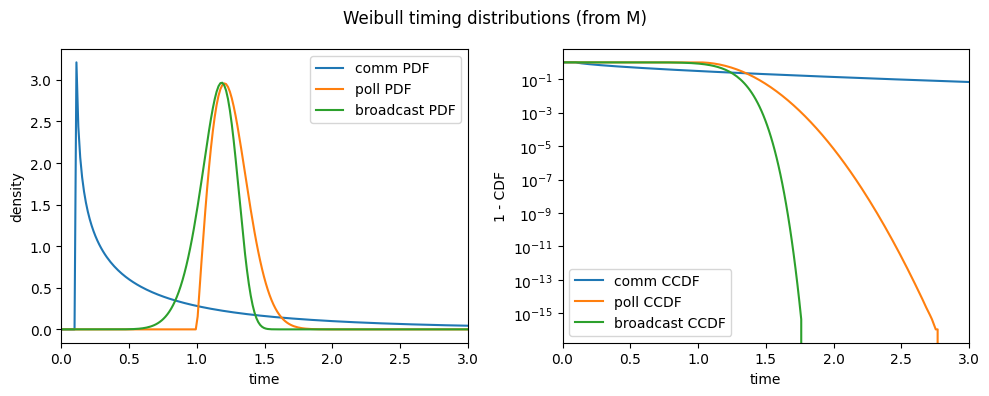

In [ ]:
"""
1) Communication latency (green curve): a heavy‑tailed Weibull governs the
   time for a posted bid to reach the auction and for broadcasts to reach
   buyers.
2) Buyer query cadence (purple curve): a peaked/shifted Weibull governs how
   often buyers *poll* for updates; they only recompute after observing a
   newer broadcast than their last seen tape.

Both are parameterized by (shape k, scale λ, optional shift τ₀).
"""

from __future__ import annotations

import math, heapq, json
from typing import Dict, Tuple, List, Optional, Any
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------
# Event types
# ------------------------------
BUYER_COMPUTE = 1
POST_BID      = 2
BROADCAST     = 3

# ------------------------------
# Weibull helpers
# ------------------------------

def wbl(rng: np.random.Generator, k: float, lam: float, shift: float = 0.0) -> float:
    """Sample τ = τ₀ + λ * W,  W ~ Weibull(k) with unit scale as in NumPy.
    NumPy's Generator.weibull(k) returns samples with scale=1.
    """
    return float(shift + lam * rng.weibull(float(k)))

# ------------------------------
# Market state (dict of arrays)
# ------------------------------


def make_market(I: int,
                Q_max: float,
                epsilon: float,
                budget_range=(5.0, 20.0),
                q_range=(50.0, 100.0),
                p_range=(10.0, 20.0),
                seed: int = 12345,
                run_seed: Optional[int] = None,
                jitter: float = 0.01,
                # Weibull timing defaults: tuned to resemble the figure
                wbl_comm: Dict[str, float] = None,
                wbl_poll: Dict[str, float] = None,
                wbl_broadcast: Dict[str, float] = None) -> Dict:
    """
    Create a market with I buyers and a single seller of capacity Q_max.

    Two RNG streams:
      - rng_init: draws buyer primitives (b, qbar, kappa) and random initial bids
      - rng_run : drives event timing (queries, network latencies)

    Timing distributions (Weibull):
      - wbl_comm:    network latency for POST_BID delivery (green)
      - wbl_poll:    buyer polling cadence between checks (purple)
      - wbl_broadcast: latency to publish tape after applying a bid (green)
    """
    seed_init = int(seed)
    seed_run  = int(seed_init + 1 if run_seed is None else run_seed)

    rng_init = np.random.default_rng(seed_init)
    rng_run  = np.random.default_rng(seed_run)

    if wbl_comm is None:       wbl_comm = {"k": 78, "lam": 417, "shift": 0.1}
    if wbl_poll is None:       wbl_poll = {"k": 272, "lam": 262, "shift": 1000.0}
    if wbl_broadcast is None:  wbl_broadcast = {"k": 1.3, "lam": 0.06, "shift": 0.0}

    b = rng_init.uniform(*budget_range, size=I)
    qbar = rng_init.uniform(*q_range, size=I)
    pbar = rng_init.uniform(*p_range, size=I)
    kappa = pbar/qbar
    bid_q = np.zeros(I, dtype=float)
    bid_p = np.zeros(I, dtype=float)

    M = {
        "I": I,
        "Q_max": float(Q_max),
        "epsilon": float(epsilon),
        "b": b,
        "qbar": qbar,
        "kappa": kappa,
        "bid_q": bid_q,
        "bid_p": bid_p,
        # public tape (what buyers can observe)
        "tape_q": np.zeros(I, dtype=float),
        "tape_p": np.zeros(I, dtype=float),
        "tape_t": 0.0,
        # last broadcast timestamp each buyer has seen (for polling)
        "last_seen": np.zeros(I, dtype=float),
        # priority queue: (timestamp, seq, etype, payload)
        "pq": [],
        "seq": 0,
        "t": 0.0,
        # timings / RNGs
        "jitter": float(jitter),
        "rng_init": rng_init,
        "rng_run": rng_run,
        "rng": rng_run,  # alias
        # Weibull timing params
        "wbl_comm": dict(wbl_comm),
        "wbl_poll": dict(wbl_poll),
        "wbl_broadcast": dict(wbl_broadcast),
        # seeds (for diagnostics/repro)
        "seed": seed_init,
        "run_seed": seed_run,
        # counters
        "compute_count": 0,
        "apply_count":   0,
        # buyer generations (staleness guard for POST_BID)
        "gen": np.zeros(I, dtype=np.int64),
    }
    return M

# ------------------------------
# Reserve buyer (fixed unit price for full Q_max)
# ------------------------------

def add_reserve_buyer(M: Dict, price: float) -> None:
    """Append a synthetic reserve buyer R that bids (q=Q_max, p=price) forever.
    R does not poll or recompute; it simply occupies the book as a standing bid.
    We set κ_R=0 so it has zero valuation and does not affect welfare sums.
    """
    I0 = int(M["I"])  # current number of buyers
    M["reserve_idx"] = I0
    M["I"] = I0 + 1

    # Grow per-buyer arrays by one slot
    def _grow(a, init=0.0):
        return np.concatenate([a, np.array([init], dtype=a.dtype)])

    M["b"]      = _grow(M["b"], init=1e18)
    M["qbar"]   = _grow(M["qbar"], init=float(M["Q_max"]))
    M["kappa"]  = _grow(M["kappa"], init=0.0)  # zero valuation
    M["bid_q"]  = _grow(M["bid_q"], init=float(M["Q_max"]))
    M["bid_p"]  = _grow(M["bid_p"], init=float(price))
    M["tape_q"] = _grow(M["tape_q"], init=float(M["Q_max"]))
    M["tape_p"] = _grow(M["tape_p"], init=float(price))
    M["last_seen"] = _grow(M["last_seen"], init=0.0)
    M["gen"]    = np.concatenate([M["gen"], np.array([0], dtype=np.int64)])

    # Ensure the public tape reflects reserve immediately if it's the only bid
    M["tape_t"] = float(M.get("tape_t", 0.0))

# ------------------------------
# Math primitives (vector-friendly)
# ------------------------------

def theta_i(i: int, z: float, M: Dict) -> float:
    m = min(z, float(M["qbar"][i]))
    k = float(M["kappa"][i])
    return k * float(M["qbar"][i]) * m - 0.5 * k * m * m

def theta_i_prime(i: int, z: float, M: Dict) -> float:
    q = float(M["qbar"][i])
    k = float(M["kappa"][i])
    return k * (q - z) if z < q else 0.0

def _others_mask(i: int, I: int) -> np.ndarray:
    m = np.ones(I, dtype=bool); m[i] = False; return m

def Q_i(i: int, p_i: float, M: Dict) -> float:
    mask = _others_mask(i, M["I"])
    rem = M["Q_max"] - float(np.sum(M["bid_q"][mask][M["bid_p"][mask] > p_i]))
    return max(rem, 0.0)

def Q_i_bar(i: int, p_i: float, M: Dict) -> float:
    mask = _others_mask(i, M["I"])
    rem = M["Q_max"] - float(np.sum(M["bid_q"][mask][M["bid_p"][mask] >= p_i]))
    return max(rem, 0.0)

def P_i(i: int, z: float, M: Dict) -> float:
    others = _others_mask(i, M["I"])
    cand = np.unique(np.concatenate(([0.0], M["bid_p"][others])))
    for y in cand:
        if Q_i(i, float(y), M) >= z:
            return float(y)
    return float("inf")

def build_price_ladder(i: int, M: Dict) -> List[Tuple[float, float]]:
    others = _others_mask(i, M["I"])
    cand = np.unique(np.concatenate(([0.0], M["bid_p"][others])))
    cand = cand[np.isfinite(cand)]
    cand.sort()
    ladder: List[Tuple[float, float]] = []
    prev = 0.0
    prev_rem = Q_i(i, float(cand[0]), M)
    tol = 1e-12
    if prev_rem > tol:
        ladder.append((prev_rem - prev, float(cand[0])))
        prev = prev_rem
    for y in cand[1:]:
        rem = Q_i(i, float(y), M)
        delta = rem - prev
        if delta > tol:
            ladder.append((float(delta), float(y)))
            prev = rem
    return ladder


def integral_P(i: int, z: float, M: Dict, ladder: Optional[List[Tuple[float,float]]] = None) -> float:
    if z <= 0.0:
        return 0.0
    if ladder is None:
        ladder = build_price_ladder(i, M)
    rem = float(z)
    cost = 0.0
    for size, price in ladder:
        if rem <= 0.0:
            break
        take = min(size, rem)
        cost += take * price
        rem -= take
    return float(cost)


def a_i(i: int, M: Dict) -> float:
    q, p = float(M["bid_q"][i]), float(M["bid_p"][i])
    return min(q, Q_i_bar(i, p, M))

def c_i(i: int, M: Dict) -> float:
    return integral_P(i, a_i(i, M), M)

def payment_i(i: int, M: Dict) -> float:
    a_with = np.array([a_i(k, M) for k in range(M["I"])], float)
    W_with = sum(theta_i(k, a_with[k], M) for k in range(M["I"]) if k != i)
    qi, pi = M["bid_q"][i], M["bid_p"][i]
    M["bid_q"][i], M["bid_p"][i] = 0.0, 0.0
    a_wo = np.array([a_i(k, M) for k in range(M["I"])], float)
    W_wo = sum(theta_i(k, a_wo[k], M) for k in range(M["I"]) if k != i)
    M["bid_q"][i], M["bid_p"][i] = qi, pi
    return W_wo - W_with

def u_i(i: int, M: Dict) -> float:
    a = a_i(i, M)
    return theta_i(i, a, M) - c_i(i, M)

# ------------------------------
# Best response quantities
# ------------------------------

def sup_G_i(i: int, M: Dict) -> float:
    ladder = build_price_ladder(i, M)
    kappa = float(M["kappa"][i])
    qbar  = float(M["qbar"][i])
    budget = float(M["b"][i])
    z = 0.0
    cost = 0.0
    for size, r in ladder:
        if z >= qbar:
            break
        add_demand = qbar - z
        if kappa > 0.0:
            z_marg_lim = max(0.0, qbar - r / kappa)
        else:
            z_marg_lim = 0.0
        add_marg = max(0.0, z_marg_lim - z)
        add_budget = float("inf") if r <= 0.0 else max(0.0, (budget - cost) / r)
        add = min(size, add_demand, add_marg, add_budget)
        if add <= 0.0:
            break
        z    += add
        cost += add * r
        if add < size:
            break
    return float(z)

def compute_t_i(i: int, M: Dict) -> Tuple[float, float]:
    Gsup = sup_G_i(i, M)
    base = theta_i_prime(i, 0.0, M)
    v = max(Gsup - (float(M["epsilon"]) / base if base > 0 else 0.0), 0.0)
    w = theta_i_prime(i, v, M)
    return v, w

# ------------------------------
# Priority queue engine
# ------------------------------

def push(M: Dict, t: float, etype: int, payload: Any):
    M.setdefault("seq", 0)
    M["seq"] += 1
    heapq.heappush(M["pq"], (float(t), int(M["seq"]), int(etype), payload))


def pop(M: Dict):
    return heapq.heappop(M["pq"]) if M["pq"] else None


def schedule_all_buyers(M: Dict, t0: float = 0.0):
    rng = M["rng"]
    k, lam, s = M["wbl_poll"]["k"], M["wbl_poll"]["lam"], M["wbl_poll"].get("shift", 0.0)
    r = int(M.get("reserve_idx", -1))
    for i in range(M["I"]):
        if i == r:
            continue  # reserve does not poll
        push(M, t0 + wbl(rng, k, lam, s), BUYER_COMPUTE, (i,))

    return M


# ------------------------------
# Event handlers
# ------------------------------

def handle_buyer_compute(M: Dict, CLOCK: Dict, i: int, verbose: bool = False):
    M["compute_count"] += 1
    rng = M["rng"]
    now = float(M["t"])

    # Polling rule: only recompute when we've seen a new broadcast
    if M["tape_t"] <= M["last_seen"][i]:
        # schedule another poll (purple Weibull)
        k, lam, s = M["wbl_poll"]["k"], M["wbl_poll"]["lam"], M["wbl_poll"].get("shift", 0.0)
        push(M, now + wbl(rng, k, lam, s), BUYER_COMPUTE, (i,))
        return False

    # mark that we've consumed the latest tape
    M["last_seen"][i] = float(M["tape_t"])

    # Work off the broadcast (observable) tape
    M_obs = get_view(M, view="tape")
    old_q, old_p = M_obs["bid_q"][i], M_obs["bid_p"][i]
    old_u = u_i(i, M_obs)
    old_cost = c_i(i, M_obs)

    v, w = compute_t_i(i, M_obs)

    M_obs["bid_q"][i], M_obs["bid_p"][i] = v, w
    new_u = u_i(i, M_obs)
    M_obs["bid_q"][i], M_obs["bid_p"][i] = old_q, old_p

    if new_u <= old_u + float(M["epsilon"]) and old_cost <= M["b"][i]:
        # No improvement → just schedule next poll
        k, lam, s = M["wbl_poll"]["k"], M["wbl_poll"]["lam"], M["wbl_poll"].get("shift", 0.0)
        push(M, now + wbl(rng, k, lam, s), BUYER_COMPUTE, (i,))
        return False

    # schedule POST_BID with *communication latency* (green Weibull)
    M["gen"][i] += 1
    gen_now = int(M["gen"][i])
    kc, lc, sc = M["wbl_comm"]["k"], M["wbl_comm"]["lam"], M["wbl_comm"].get("shift", 0.0)
    deliver_at = now + wbl(rng, kc, lc, sc)
    push(M, deliver_at, POST_BID,
         {"i": int(i), "v": float(v), "w": float(w), "t_send": float(now), "gen": gen_now})

    # also schedule next poll (buyers keep polling until next broadcast)
    k, lam, s = M["wbl_poll"]["k"], M["wbl_poll"]["lam"], M["wbl_poll"].get("shift", 0.0)
    push(M, now + wbl(rng, k, lam, s), BUYER_COMPUTE, (i,))
    return True


def handle_post_bid(M: Dict, CLOCK: Dict, i: int, v: float, w: float, t_send: float, gen: int,
                    verbose: bool = False):
    # Stale guard
    if int(M["gen"][i]) != int(gen):
        return False

    # Record transmission delay/margin for diagnostics
    delay = max(0.0, float(M["t"]) - float(t_send))
    old_u = u_i(i, M)
    prev_q, prev_p = M["bid_q"][i], M["bid_p"][i]
    M["bid_q"][i], M["bid_p"][i] = v, w
    new_u = u_i(i, M)
    M["bid_q"][i], M["bid_p"][i] = prev_q, prev_p
    margin = new_u - old_u - float(M["epsilon"])

    CLOCK.setdefault("delay", np.full(M["I"], np.nan))
    CLOCK.setdefault("margin", np.full(M["I"], np.nan))
    CLOCK.setdefault("delay_count", np.zeros(M["I"], dtype=np.int64))
    CLOCK["delay"][i] = float(delay)
    CLOCK["margin"][i] = float(margin)
    CLOCK["delay_count"][i] += 1

    # Apply and schedule broadcast with network latency
    M["bid_q"][i], M["bid_p"][i] = v, w
    M["apply_count"] += 1

    kb, lb, sb = M["wbl_broadcast"]["k"], M["wbl_broadcast"]["lam"], M["wbl_broadcast"].get("shift", 0.0)
    push(M, float(M["t"]) + wbl(M["rng"], kb, lb, sb), BROADCAST, None)
    return True


def handle_broadcast(M: Dict):
    # Publish the live book to the public tape
    M["tape_q"] = M["bid_q"].copy()
    M["tape_p"] = M["bid_p"].copy()
    M["tape_t"] = float(M["t"])

# ------------------------------
# Runner
# ------------------------------

def run(M: Dict, CLOCK: Dict, steps: int = 1000, verbose: bool = False):
    for _ in range(steps):
        item = pop(M)
        if item is None:
            break
        t, _, etype, payload = item
        M["t"] = float(t)
        if etype == BUYER_COMPUTE:
            (i,) = payload
            handle_buyer_compute(M, CLOCK, int(i), verbose=verbose)
        elif etype == POST_BID:
            i = int(payload["i"]); v = float(payload["v"]); w = float(payload["w"])
            t_send = float(payload["t_send"]); gen = int(payload["gen"])
            handle_post_bid(M, CLOCK, i, v, w, t_send, gen, verbose=verbose)
        elif etype == BROADCAST:
            handle_broadcast(M)
        else:
            raise RuntimeError(f"Unknown event type: {etype}")

# ------------------------------
# Diagnostics / Reporting
# ------------------------------

def market_config(M: Dict, round_decimals: int = 3, verbose: bool = False):
    I = M["I"]
    df_buyers = pd.DataFrame({
        "Buyer": [f"B_{i}" for i in range(I)],
        "b_i":   np.round(M["b"], round_decimals),
        "q̄_i":   np.round(M["qbar"], round_decimals),
        "κ_i":   np.round(M["kappa"], round_decimals),
    })
    meta = {
        "I": I,
        "Q_max": M["Q_max"],
        "epsilon": M["epsilon"],
        "seed": M.get("seed"),
        "run_seed": M.get("run_seed"),
        "weibull_comm": M["wbl_comm"],
        "weibull_poll": M["wbl_poll"],
        "weibull_broadcast": M["wbl_broadcast"],
    }
    df_meta = pd.DataFrame([meta])
    if verbose:
        print("=== Market Config ===")
        print(df_meta.to_string(index=False))
        print("=== Buyers ===")
        print(df_buyers.to_string(index=False))
    return df_meta, df_buyers


def a_i_vec(M: Dict) -> np.ndarray:
    return np.array([a_i(i, M) for i in range(M["I"])], dtype=float)


def snapshot(M: Dict,
             cols: Tuple[str, ...] = ("Buyer","q_i","p_i","a_i","cost","payment","u_i","budget","slack"),
             round_decimals: int = 3,
             verbose: bool = False) -> pd.DataFrame:
    """Row per buyer with computed fields; optional totals row."""
    I = M["I"]
    t = M["t"]
    rows = []
    for i in range(I):
        row = {
            "Buyer": f"B_{i}",
            "q_i": float(M["bid_q"][i]),
            "p_i": float(M["bid_p"][i]),
            "a_i": a_i(i, M),
            "cost": c_i(i, M),
            "payment": payment_i(i,M),
            "u_i": u_i(i, M),
            "budget": float(M["b"][i]),
            "slack": float(M["b"][i]) - c_i(i, M),
        }
        rows.append(row)
    df = pd.DataFrame(rows, cols)
    if verbose:
        df = df.round(round_decimals)
        print(f"\n=== Snapshot t={t:.4f} ===")
        print(df.to_string(index=False))
    return df

def market_info(M: Dict, round_decimals = 3, verbose: bool = False) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Compute stats from the current live book.
    Returns a totals and summary metrics.
    """
    I = M["I"]
    t = M["t"]
    rows = []
    r = int(M.get("reserve_idx", -1))  # ensure reserve index is defined
    for i in range(I):
        row = {
            "Buyer": ("R" if i == r else f"B_{i}"),
            "q_i": float(M["bid_q"][i]),
            "p_i": float(M["bid_p"][i]),
            "a_i": a_i(i, M),
            "cost": c_i(i, M),
            "payment": payment_i(i,M),
            "value": theta_i(i, a_i(i, M), M),
            "u_i": u_i(i, M),
            "budget": float(M["b"][i]),
            "slack": float(M["b"][i]) - c_i(i, M),
        }
        rows.append(row)
    df = pd.DataFrame(rows)
    if verbose:
        df = df.round(round_decimals)
        print(f"\n=== Buyer Snapshot t={t:.4f} ===")
        print(df.to_string(index=False))

    Q_max = M["Q_max"]
    bid_q = np.asarray(M.get("bid_q", np.zeros(0)), dtype=float)[:I]
    bid_p = np.asarray(M.get("bid_p", np.zeros(0)), dtype=float)[:I]

    # Per-buyer derived stats
    a = np.array([a_i(i, M) for i in range(I)], dtype=float)[:I]
    cost = np.array([c_i(i, M) for i in range(I)], dtype=float)[:I]
    value = np.array([theta_i(i, a_i(i, M), M) for i in range(I)], dtype=float)[:I]
    spend = np.array([payment_i(i, M) for i in range(I)], dtype=float)[:I]
    util = np.array([u_i(i, M) for i in range(I)], dtype=float)[:I]

    total_requested = float(np.sum(bid_q))
    total_allocated = float(np.sum(a))
    total_cost = float(np.sum(cost))
    total_value = float(np.sum(value))
    total_spend = float(np.sum(spend))
    total_utility = float(np.sum(util))

    df_tot = pd.DataFrame({
        "I": I,
        "Q_max": Q_max,
        "total_request": total_requested,
        "total_alloc": total_allocated,
        "total_cost": total_cost,
        "total_value": total_value,
        "total_spend": total_spend,
        "total_util": total_utility,
        "avg_bid_price": float(np.mean(bid_p)),
        "med_bid_price": float(np.median(bid_p)),
    }, index=[0])
    if verbose:
        print(f"=== Market Summary t={t:.4f} ===")
        df_tot = df_tot.round(round_decimals)
        print(df_tot.to_string(index=False))
    return df, df_tot

# ------------------------------
# Clock
# ------------------------------

def init_clock(I: int):
    return {
        "I": int(I),
        "delay":  np.full(I, np.nan),
        "margin": np.full(I, np.nan),
        "delay_count": np.zeros(I, dtype=np.int64),
    }

# ------------------------------
# Initialization helpers
# ------------------------------

def rand_bids(M: Dict, alpha_range=(0.1, 0.3)):
    rng0 = M.get("rng_init", M.get("rng"))
    a_lo, a_hi = float(alpha_range[0]), float(alpha_range[1])
    r = int(M.get("reserve_idx", -1))
    for i in range(M["I"]):
        if i == r:
            continue  # keep reserve fixed
        qbar_i = float(M["qbar"][i])
        alpha_i = float(rng0.uniform(a_lo, a_hi))
        alpha_i = max(0.0, min(alpha_i, 1.0))
        v0 = alpha_i * qbar_i
        w0 = theta_i_prime(i, v0, M)
        M["bid_q"][i], M["bid_p"][i] = float(v0), float(w0)
    # publish initial state to the tape so buyers can observe something
    M["tape_q"] = M["bid_q"].copy()
    M["tape_p"] = M["bid_p"].copy()


def fair_bids(M: Dict, uniform_price: bool = False):
    """Initialize bids to a *perceived fair share*.

    Each non-reserve buyer i bids q_i = min(q̄_i, Q_max / N_active).
    Prices are:
      - individualized (default): p_i = θ′_i(q_i)
      - uniform (uniform_price=True): p_i = median_j θ′_j(q_j)

    Reserve (if present) is excluded and kept fixed.
    After setting bids, the public tape is updated.
    """
    I = int(M["I"])
    r = int(M.get("reserve_idx", -1))
    act = [i for i in range(I) if i != r]
    N = len(act)
    if N == 0:
        # nothing to do
        M["tape_q"] = M["bid_q"].copy()
        M["tape_p"] = M["bid_p"].copy()
        return

    base_share = float(M["Q_max"]) / float(N)
    q_star = {i: float(min(M["qbar"][i], base_share)) for i in act}

    if uniform_price:
        vals = [theta_i_prime(i, q_star[i], M) for i in act]
        ref = float(np.median(np.asarray(vals, dtype=float)))
        for i in act:
            M["bid_q"][i] = q_star[i]
            M["bid_p"][i] = ref
    else:
        for i in act:
            M["bid_q"][i] = q_star[i]
            M["bid_p"][i] = theta_i_prime(i, q_star[i], M)

    # publish to tape so buyers can observe something immediately
    M["tape_q"] = M["bid_q"].copy()
    M["tape_p"] = M["bid_p"].copy()


# ------------------------------
# Ensemble helpers (unchanged shape; minimal version for brevity)
# ------------------------------

def run_until_idle(M: Dict, CLOCK: Dict, *, window: int = 2000, patience: int = 3,
                   max_windows: int = 50, tol: float = 1e-9, verbose: bool = False) -> None:
    idle_streak = 0
    last_applies = int(M["apply_count"])
    last_q = M["bid_q"].copy(); last_p = M["bid_p"].copy()
    for _ in range(max_windows):
        run(M, CLOCK, steps=window, verbose=verbose)
        t = M["t"]
        new_applies = int(M["apply_count"])
        dq = float(np.max(np.abs(M["bid_q"] - last_q)))
        dp = float(np.max(np.abs(M["bid_p"] - last_p)))
        stationary = (new_applies == last_applies) and (dq < tol) and (dp < tol)
        idle_streak = idle_streak + 1 if stationary else 0
        if verbose:
            print(f"[t {t:.4f}] applies Δ={new_applies-last_applies}, maxΔq={dq:.3e}, maxΔp={dp:.3e}, idle={idle_streak}/{patience}")
        if idle_streak >= patience:
            break
        last_applies = new_applies
        last_q[:] = M["bid_q"]; last_p[:] = M["bid_p"]


# ------------------------------
# Weibull plotting helpers
# ------------------------------

def weibull_shifted_pdf_cdf(t: np.ndarray, k: float, lam: float, shift: float = 0.0) -> Tuple[np.ndarray, np.ndarray]:
    """PDF and CDF of a shifted Weibull: T = shift + lam * W, W ~ Weibull(k, scale=1).
    Support is t >= shift. Returns (pdf, cdf) as arrays matching t.
    """
    t = np.asarray(t, dtype=float)
    x = np.maximum(t - float(shift), 0.0) / float(lam)
    with np.errstate(over='ignore', divide='ignore', invalid='ignore'):
        e = np.exp(-np.power(x, float(k)))
        pdf = np.where(t >= float(shift), (float(k) / float(lam)) * np.power(x, float(k) - 1.0) * e, 0.0)
        cdf = np.where(t >= float(shift), 1.0 - e, 0.0)
    return pdf, cdf


def plot_weibull_curves(M: Dict, t_max: Optional[float] = None, n: int = 800,
                        sample: int = 0, rng: Optional[np.random.Generator] = None):
    """Plot PDFs and CCDFs for the timing Weibulls stored in M.

    Args:
      M: market dict containing "wbl_comm", "wbl_poll", "wbl_broadcast".
      t_max: right end of time axis. If None, choose 99.9th percentile across curves.
      n: number of points on the time grid.
      sample: optional number of samples per curve to overlay as a density hist on the PDF plot.
      rng: optional RNG for sampling; default uses a fixed-seed generator for reproducibility.

    Returns:
      matplotlib.figure.Figure with two subplots: PDF (left) and CCDF (right, log scale).
    """
    curves = [("comm", M["wbl_comm"]), ("poll", M["wbl_poll"]), ("broadcast", M["wbl_broadcast"])]

    def q999(p):
        k = float(p["k"]); lam = float(p["lam"]); s = float(p.get("shift", 0.0))
        return s + lam * (-np.log(1.0 - 0.999))**(1.0 / k)

    if t_max is None:
        t_max = max(q999(p) for _, p in curves)

    t = np.linspace(0.0, float(t_max), int(n))
    fig, (ax_pdf, ax_ccdf) = plt.subplots(1, 2, figsize=(10, 4))

    for name, p in curves:
        k = float(p["k"]); lam = float(p["lam"]); s = float(p.get("shift", 0.0))
        pdf, cdf = weibull_shifted_pdf_cdf(t, k, lam, s)
        ax_pdf.plot(t, pdf, label=f"{name} PDF")
        ax_pdf.set_xlim(0.0, 3.0)
        ax_ccdf.plot(t, 1.0 - cdf, label=f"{name} CCDF")
        ax_ccdf.set_xlim(0.0, 3.0)
        if sample and sample > 0:
            R = rng or np.random.default_rng(123)
            samp = s + lam * R.weibull(k, size=int(sample))
            ax_pdf.hist(samp, bins=50, density=True, alpha=0.2, label=f"{name} samples")

    ax_pdf.set_xlabel("time")
    ax_pdf.set_ylabel("density")
    ax_pdf.legend()

    ax_ccdf.set_xlabel("time")
    ax_ccdf.set_ylabel("1 - CDF")
    ax_ccdf.set_yscale("log")
    ax_ccdf.legend()

    fig.suptitle("Weibull timing distributions (from M)")
    fig.tight_layout()
    return fig

# ------------------------------
# Ensemble experiment helpers
# ------------------------------

def clearing_price(M: Dict) -> float:
    """Compute the single-seller clearing price p* such that
    sum_{p>p*} q < Q_max <= sum_{p>=p*} q.
    If total requested <= Q_max, returns the minimum posted price (e.g., reserve).
    """
    p = np.asarray(M["bid_p"], dtype=float)
    q = np.asarray(M["bid_q"], dtype=float)
    Q = float(M["Q_max"])
    uniq = np.unique(p[np.isfinite(p)])
    if uniq.size == 0:
        return 0.0
    uniq.sort()
    for y in uniq:
        s_strict = float(np.sum(q[p > y]))
        s_ge = float(np.sum(q[p >= y]))
        if s_strict < Q <= s_ge + 1e-12:
            return float(y)
    # under-demanded: price floor
    return float(uniq[0])

def reserve_sweep_experiment(config_base: str,
                             r_min: float = 1.0,
                             r_max: float = 20.0,
                             num: int = 20,
                             *,
                             init: str = "fair",           # "fair" or "rand"
                             window: int = 1500,
                             patience: int = 3,
                             max_windows: int = 40,
                             run_stride: int = 17,
                             verbose: bool = False) -> Tuple[pd.DataFrame, plt.Figure]:
    """Sweep the reserve price over [r_min, r_max] and measure the market clearing price.

    Args:
      config_base: JSON string with at least I, Q_max, epsilon, seed, run_seed.
      r_min, r_max, num: range and number of reserve price points.
      init: initializer for bids ("fair" or "rand").
      window/patience/max_windows: convergence controls for run_until_idle.

    Returns: (df, fig)
      df columns: reserve_price, market_price, total_alloc, total_request
      fig: matplotlib Figure with market_price vs reserve_price and y=x line.
    """
    base = json.loads(config_base)
    prices = np.linspace(float(r_min), float(r_max), int(num))
    rows = []
    for k, rprice in enumerate(prices):
        params = dict(base)
        params["reserve_price"] = float(rprice)
        # keep primitives fixed; vary only run_seed per sweep step for stability
        params["run_seed"] = int(base.get("run_seed", params.get("seed", 2025))) + k * int(run_stride)
        cfg = json.dumps(params, sort_keys=True, separators=(",", ":"))

        M, CLOCK, _ = build_market(cfg, init=init)

        schedule_all_buyers(M, t0=0.0)

        run_until_idle(M, CLOCK, window=window, patience=patience, max_windows=max_windows, verbose=verbose)

        p_star = clearing_price(M)
        total_req = float(np.sum(M["bid_q"]))
        total_alloc = float(np.sum([a_i(i, M) for i in range(M["I"])]))
        rows.append({
            "reserve_price": float(rprice),
            "market_price": float(p_star),
            "total_request": total_req,
            "total_alloc": total_alloc,
        })

    df = pd.DataFrame(rows).sort_values("reserve_price").reset_index(drop=True)

    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    ax.plot(df["reserve_price"].values, df["market_price"].values, marker="o")
    ax.plot(df["reserve_price"].values, df["reserve_price"].values, linestyle="--", label="y = x")
    ax.set_xlabel("reserve price")
    ax.set_ylabel("market clearing price p*")
    ax.set_title("Market price vs reserve price (single seller)")
    ax.legend()
    fig.tight_layout()
    return df, fig

# ------------------------------

def replicate_run(config_str: str, *, init: str,
                   window: int, patience: int, max_windows: int,
                   verbose: bool=False) -> Tuple[pd.DataFrame, pd.DataFramee]:
      M, CLOCK, _ = build_market(config_str, init=init)
      schedule_all_buyers(M, t0=0.0)
      run_until_idle(M, CLOCK, window=window, patience=patience,
                     max_windows=max_windows, verbose=verbose)
      I = M["I"]
      alloc = np.array([a_i(i, M) for i in range(I)], dtype=float)
      vals  = np.array([theta_i(i, alloc[i], M) for i in range(I)], dtype=float)
      res, info = market_info(M, verbose=verbose)
      return res, info

def ensemble_experiment(config: str, L: int = 100, *, init: str = "rand",
                         window: int = 2000, patience: int = 3, max_windows: int = 50,
                         verbose: bool = False, run_stride = 1) -> Dict[str, Any]:
    """Run L replicates to approximate an ensemble of ε-NE outcomes s^ℓ(t_∞).

    Returns a dict containing per-buyer expectations and per-replicate diagnostics.
    We include the variance of θ_i(a_i(s^ℓ(t_∞))).

    Variance convention:
        - If unbiased=False (default): Var = E[X^2] − (E[X])^2  (population formula).
        - If unbiased=True:  Var = sample variance with ddof=1.
    """
    _, _, base_cfg = build_market(config, init=init)
    print(base_cfg)
    base = json.loads(base_cfg)
    base_init_seed = int(base.get("seed", 2025))
    base_run_seed  = int(base.get("run_seed", base_init_seed + 1))

    # Collect per-replicate results
    per_rep = []
    per_rep_info = []
    for ell in range(L):
        params = dict(base)
        # Keep the market primitives fixed; vary only the runtime RNG
        params["seed"] = base_init_seed
        params["run_seed"] = base_run_seed + ell * int(run_stride)
        cfg = json.dumps(params, sort_keys=True, separators=(",", ":"))
        res, info = replicate_run(cfg, init=init,
                                  window=window, patience=patience,
                                  max_windows=max_windows,
                                  verbose=verbose)
        res["ell"] = ell
        res["seed"] = params["seed"]
        res["run_seed"] = params["run_seed"]
        per_rep.append(res)
        per_rep_info.append(info)

    I = params["I"]
    # Stack values and allocations
    allocs = np.stack([r["a_i"] for r in per_rep], axis=0)[:I]  # (L, I)
    costs = np.stack([r["cost"] for r in per_rep], axis=0)[:I]  # (L, I)
    utils = np.stack([r["u_i"] for r in per_rep], axis=0)[:I]  # (L, I)
    values = np.stack([r["value"] for r in per_rep], axis=0)[:I]  # (L, I)
    payments = np.stack([r["payment"] for r in per_rep], axis=0)[:I]  # (L, I)
    bids_q = np.stack([r["q_i"] for r in per_rep], axis=0)[:I]
    bids_p = np.stack([r["p_i"] for r in per_rep], axis=0)[:I]

    # Moments for θ_i(a_i)
    E_theta = values.mean(axis=0)[:I]
    E_theta2 = (values * values).mean(axis=0)[:I]
    Var_theta = np.maximum(E_theta2 - E_theta * E_theta, 0.0)[:I]
    Std_theta = np.sqrt(Var_theta)[:I]

    # Also provide expectations for a_i, q_i, p_i (means only)
    E_alloc = allocs.mean(axis=0)[:I]
    E_q = bids_q.mean(axis=0)[:I]
    E_p = bids_p.mean(axis=0)[:I]

    # Wrap into DataFrames for convenience
    df_E = pd.DataFrame({
        "i": np.arange(I, dtype=int),
        "E_theta": E_theta,
        "Var_theta": Var_theta,
        "Std_theta": Std_theta,
        "E_alloc": E_alloc,
        "E_q": E_q,
        "E_p": E_p,
    })

    totals_util = np.array([r["total_util"] for r in per_rep_info], dtype=float)
    totals_spend = np.array([r["total_spend"] for r in per_rep_info], dtype=float)
    totals_cost = np.array([r["total_cost"] for r in per_rep_info], dtype=float)
    totals_value = np.array([r["total_value"] for r in per_rep_info], dtype=float)
    totals_alloc = np.array([r["total_alloc"] for r in per_rep_info], dtype=float)

    df_info = pd.DataFrame({
        "util_mean": float(np.mean(totals_util)),
        "util_std": float(np.std(totals_util, ddof=1)),
        "cost_mean": float(np.mean(totals_cost)),
        "cost_std": float(np.std(totals_cost, ddof=1)),
        "spend_mean": float(np.mean(totals_spend)),
        "spend_std": float(np.std(totals_spend, ddof=1)),
        "alloc_mean": float(np.mean(totals_alloc)),
        "alloc_std": float(np.std(totals_alloc, ddof=1)),
    }, index=[0])

    return {
        "E": df_E,
        "info": df_info,
        "base_cfg": base_cfg,
        "config": config,
        "values": values,
        "allocs": allocs,
        "bids_q": bids_q,
        "bids_p": bids_p,
    }

def do_ensemble_experiment():
    """Run a short ensemble with a reserve buyer example.
    This demo adds a standing reserve at price 0.5 for full Q_max.
    """
    print("=== Ensemble Experiment ===")
    cfg = '{"I":100,"Q_max":100.0,"epsilon":5.0,"seed":2025,"run_seed":9001,' \
          '"jitter":0.0,"random_init":true,"reserve_price":0.5}'

    E = ensemble_experiment(cfg, L=4, init="rand", run_stride=555, verbose=True)

    print("=== Ensemble E[θ_i], E[a_i], E[q_i], E[p_i] ===")
    print(E["E"].round(3).to_string(index=False))
    print(E["info"].round(3).to_string(index=False))

def build_market(config: str = "", init: str = "rand"):
    p = json.loads(config)
    reserve_price = p.get("reserve_price", None)

    wbl_comm = {"k": 0.7, "lam": 0.7, "shift": 0.1}
    wbl_poll = {"k": 2, "lam": 0.29, "shift": 1.0}
    wbl_broadcast = {"k": 8, "lam": 1.0, "shift": 0.2}

    M = make_market(I=int(p["I"]), Q_max=float(p["Q_max"]), epsilon=float(p["epsilon"]),
                    seed=int(p["seed"]), run_seed=int(p["run_seed"]), jitter=float(p.get("jitter", 0.01)),
                    wbl_comm=wbl_comm, wbl_poll=wbl_poll, wbl_broadcast=wbl_broadcast)
    if reserve_price is not None:
        add_reserve_buyer(M, float(reserve_price))
    if init == "fair":
        fair_bids(M)
    else:
        rand_bids(M)
    CLOCK = init_clock(I=M["I"])
    config_used = {
        "I": int(p["I"]),
        "Q_max": float(p["Q_max"]),
        "epsilon": float(p["epsilon"]),
        "seed": int(p["seed"]),
        "run_seed": int(p["run_seed"]),
        "jitter": float(p.get("jitter", 0.01)),
        "init": init,
        "reserve_price": float(reserve_price) if reserve_price is not None else None,
    }
    config_str = json.dumps(config_used, sort_keys=True, separators=(",", ":"))
    return M, CLOCK, config_str

if __name__ == "__main__":


    #do_ensemble_experiment()

    # base config with your usual primitives (no reserve_price needed here)
    cfg = '{"I":60,"Q_max":100.0,"epsilon":5.0,"seed":2025,"run_seed":9001,"jitter":0.0}'

    M, CLOCK, _ = build_market(cfg, init="rand")

    # schedule buyers
    schedule_all_buyers(M, t0=0.0)
    plot_weibull_curves(M)
    plt.show()

    #df, fig = reserve_sweep_experiment(cfg, r_min=1.0, r_max=20.0, num=20,
    #                                  init="rand", window=1500, patience=3,
    #                                  max_windows=40, verbose=False)

    #print(df.head())
    # plt.show()  # if you're running interactively

